# JAX-Compatible Quantum Rotation Optimization

This notebook demonstrates gradient-based optimization of quantum rotation gates using JAX automatic differentiation and QuTiP quantum simulations. We optimize two Ry rotation angles to maximize the probability of measuring the qubit in the excited state.

## System Overview

The simulation uses a **three-system composite Hilbert space**:
1. **Input cavity**: Placeholder for future input field coupling (unused in this example)
2. **Resonator cavity**: Main cavity mode coupled to the qubit 
3. **Qubit**: Two-level system that can be rotated and measured

### Optimization Workflow:
1. **Initialize**: Start with excited resonator cavity state |0,1,0⟩ 
2. **Rotate**: Apply first Ry(θ₁) rotation to qubit
3. **Evolve**: Time evolution under cavity-qubit coupling Hamiltonian
4. **Rotate**: Apply second Ry(θ₂) rotation to qubit  
5. **Measure**: Calculate probability of qubit in |1⟩ state
6. **Optimize**: Use JAX gradients to find optimal θ₁, θ₂

## Required Libraries

Import the essential libraries for JAX-compatible quantum optimization:
- **JAX**: Automatic differentiation and numerical computing
- **QuTiP**: Quantum state manipulation and time evolution  
- **NumPy & Matplotlib**: Numerical operations and visualization
- **Optax**: JAX-based optimization algorithms

In [1]:
import jax
import qutip as qt
import qutip_jax  # Enables JAX backend for QuTiP
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
import optax  # JAX optimization library

# Verify JAX-QuTiP compatibility
print("JAX version:", jax.__version__)
print("QuTiP version:", qt.__version__)


JAX version: 0.4.35
QuTiP version: 5.2.0


## System Parameters

Key parameters for the three-system composite Hilbert space:
- **nlev**: Hilbert space dimension for each cavity (input + resonator)
- **chi**: Dispersive coupling strength between resonator and qubit
- **gm**: Resonator cavity decay rate (not used in time-independent evolution)
- **Evolution time**: Duration for Hamiltonian time evolution between rotations

In [10]:
# System parameters for three-cavity composite space: input ⊗ resonator ⊗ qubit
nlev = 2         # Number of levels in each cavity (input and resonator)
chi = 0.1        # Dispersive coupling between resonator and qubit
gm = 0.1         # Resonator cavity decay rate  
sigma = 50       # Gaussian pulse width
t_i = -5.0       # Initial time for evolution
t_f = 5.0        # Final time for evolution

# Arguments for time-dependent functions
kwargs = {"gm": gm, "sigma": sigma}

print(f"Time evolution range: [{t_i}, {t_f}]")
print(f"Composite Hilbert space dimension: {nlev} × {nlev} × 2 = {nlev * nlev * 2}")

Time evolution range: [-5.0, 5.0]
Composite Hilbert space dimension: 2 × 2 × 2 = 8


## Quantum Operators for Three-System Composite Space

Create operators for the composite Hilbert space: **input cavity ⊗ resonator cavity ⊗ qubit**

### Individual System Operators:
- **Input cavity**: Annihilation/creation operators (currently unused)
- **Resonator cavity**: Annihilation/creation operators coupled to qubit
- **Qubit**: Pauli matrices and projection operators for rotations and measurements

### Composite Operators:
All operators are embedded in the full three-system tensor product space using QuTiP's `tensor()` function with JAX backend enabled.

In [14]:
# Quantum operators for three-cavity system: input_cavity ⊗ resonator_cavity ⊗ qubit
# Create JAX-backed operators for three-system composite space
with qt.CoreOptions(default_dtype="jax"):
    # ==================== INDIVIDUAL SYSTEM OPERATORS ====================
    # Basic operators for each subsystem
    I2 = qt.qeye(2)           # Qubit identity (2×2)
    In = qt.qeye(nlev)        # Cavity identity (nlev×nlev)
    An = qt.destroy(nlev)     # Cavity annihilation operator
    Acn = qt.create(nlev)     # Cavity creation operator

    # Qubit Pauli operators
    Sx = qt.sigmax()          # σx Pauli operator
    Sy = qt.sigmay()          # σy Pauli operator  
    Sz = qt.sigmaz()          # σz Pauli operator

    # Qubit projection operators
    P0 = qt.Qobj([[1, 0], [0, 0]])  # |0⟩⟨0| projection
    P1 = qt.Qobj([[0, 0], [0, 1]])  # |1⟩⟨1| projection

    # ==================== COMPOSITE SYSTEM OPERATORS ====================
    # System structure: input_cavity ⊗ resonator_cavity ⊗ qubit

    # Input cavity operators (unused in this example, but part of full space)
    ain = qt.tensor(An, In, I2)        # Input cavity annihilation
    ainc = ain.dag()                   # Input cavity creation

    # Resonator cavity operators (main cavity coupled to qubit)
    a_res = qt.tensor(In, An, I2)      # Resonator cavity annihilation
    ac_res = a_res.dag()               # Resonator cavity creation

    # Qubit operators in composite space
    sx_qubit = qt.tensor(In, In, Sx)   # σx for qubit
    sy_qubit = qt.tensor(In, In, Sy)   # σy for qubit  
    sz_qubit = qt.tensor(In, In, Sz)   # σz for qubit

    # Qubit measurement projectors in composite space
    proj_0 = qt.tensor(In, In, P0)     # Project qubit onto |0⟩
    proj_1 = qt.tensor(In, In, P1)     # Project qubit onto |1⟩

print(f"✓ All operators use JAX backend: {type(a_res.data)}")
print("Operators ready for gradient-based optimization")

✓ All operators use JAX backend: <class 'qutip_jax.jaxarray.JaxArray'>
Operators ready for gradient-based optimization


## JAX-Compatible Quantum Functions

Define JAX-differentiable functions for quantum operations:
- **Measurement**: Calculate qubit state probabilities from density matrices
- **Rotation**: Apply Ry rotations to qubit in the composite space

These functions use direct matrix operations on JAX arrays to ensure gradient compatibility.

In [12]:
def measure_qubit(rho, state):
    """
    JAX-compatible measurement of qubit state probability.
    
    Args:
        rho: QuTiP Qobj density matrix in composite space
        state: int, 0 for |0⟩ state, 1 for |1⟩ state
        
    Returns:
        JAX array: Probability of measuring qubit in specified state
    """
    proj_op = proj_0 if state == 0 else proj_1
    rho_data = rho.data._jxa
    proj_data = proj_op.data._jxa
    temp = jnp.matmul(proj_data, rho_data)
    result = jnp.matmul(temp, jnp.conj(proj_data).T)
    return jnp.real(jnp.trace(result))

def apply_qubit_rotation(rho, theta):
    """
    Apply Ry rotation to qubit in the three-system composite space.
    
    Args:
        rho: QuTiP Qobj density matrix
        theta: float or JAX array, Ry rotation angle
        
    Returns:
        QuTiP Qobj: Rotated density matrix
    """
    with qt.CoreOptions(default_dtype="jax"):
        # Create Ry rotation gate for single qubit
        ry_gate = (-1j * Sy * theta / 2).expm()
        # Embed in composite space: input ⊗ resonator ⊗ qubit
        ry_composite = qt.tensor(In, In, ry_gate)
    
    return ry_composite * rho * ry_composite.dag()

print("JAX-compatible quantum functions defined")

JAX-compatible quantum functions defined


## System Hamiltonian

Define a simple time-independent Hamiltonian for the resonator-qubit subsystem:
- **Resonator term**: Energy of photons in the resonator cavity
- **Qubit term**: Energy splitting of the two-level system
- **Interaction term**: Dispersive coupling between resonator photons and qubit


In [44]:
import jax.numpy as jnp
from numpy import pi, sqrt, exp
from jax.scipy.special import erfc

# JAX-compatible time-dependent functions following tutorial patterns
@jax.jit 
def u0_jax(t, **kwargs):
    """Normalized Gaussian pulse shape - JAX compatible."""
    sigma = kwargs.get("sigma", 50)
    dx = sigma * t
    return jnp.exp(-dx**2)

@jax.jit
def gu(t, **kwargs):
    """Time-dependent coupling function - QuTiP compatible."""
    sigma = kwargs.get("sigma", 50)
    dx = sigma * t
    # Use numpy functions for QuTiP compatibility
    result = jnp.sqrt(2 * sigma / jnp.sqrt(pi) * jnp.exp(-dx**2) / erfc(dx))
    return result.real    # QuTiP needs Python float

# Create time-dependent Hamiltonian with corrected variable names
with qt.CoreOptions(default_dtype="jax"):
    # Time-independent dispersive coupling (qubit-resonator)
    H_dispersive = -chi * ac_res * a_res * sz_qubit
    
    # Time-dependent cavity-cavity coupling 
    H_coupling = 1j / 2 * sqrt(gm) * (ainc * a_res - ain * ac_res)
    
    # Complete time-dependent Hamiltonian
    H = qt.QobjEvo([H_dispersive, [H_coupling, gu]], args=kwargs)
    
    # Lindblad operators for dissipation
    L = [qt.QobjEvo([ain, gu],  args=kwargs) + jnp.sqrt(gm) * a_res]

    # Initial state: |0,1,0⟩ in composite space
    psi_initial = qt.tensor(qt.basis(nlev, 1), qt.basis(nlev, 0), qt.basis(2, 0))
    rho_initial = psi_initial * psi_initial.dag()
    
    sz_qubit.isherm  # Flag to ensure Hermitian operator

print("Time-dependent Hamiltonian created")

Time-dependent Hamiltonian created


## Initialize solver

In [49]:
# Create solver for time-dependent evolution
solver = qt.MESolver(H, L, options={"method": "diffrax", "normalize_output": False})

## Optimization Objective Function

Implement the complete quantum workflow as a JAX-differentiable function:

### Workflow Steps:
2. **First Rotation**: Apply Ry(θ₁) to qubit
3. **Evolution**: Time evolution under resonator-qubit coupling  
4. **Second Rotation**: Apply Ry(θ₂) to qubit
5. **Measurement**: Probability of qubit in excited state |1⟩

The objective is to maximize P(qubit=|1⟩) by optimizing rotation angles θ₁ and θ₂.

In [ ]:
def optimization_objective(solver, rho, theta1, theta2):
    """
    Complete quantum workflow with time-dependent evolution
    
    Args:
        solver: QuTiP MESolver instance for time evolution
        rho: Initial density matrix in composite space
        theta1: First Ry rotation angle
        theta2: Second Ry rotation angle
        
    Returns:
        Probability of measuring qubit in |1⟩ state
    """
        
    # Apply first rotation
    rho_after_rot1 = apply_qubit_rotation(rho, theta1)
    
    # Time evolution from t_i to t_f
    result = solver.run(rho_after_rot1, [t_i, t_f], args=kwargs)
    rho_evolved = result.states[-1]
    
    # Apply second rotation
    rho_after_rot2 = apply_qubit_rotation(rho_evolved, theta2)
    
    # Measure qubit probability
    return measure_qubit(rho_after_rot2, state=1)  # Measure |1⟩ state probability

# Test the objective function
print("Testing")
test_theta1, test_theta2 = jnp.pi/4, jnp.pi/6
test_prob = optimization_objective(solver, rho_initial, test_theta1, test_theta2)
print(f"✓ Test probability P(|1⟩) = {test_prob:.6f}")

# Test JAX gradients
print("Testing JAX gradients...")
grad_fn = jax.grad(optimization_objective, argnums=(2, 3))
grads = grad_fn(solver, rho_initial, test_theta1, test_theta2)
print(f"✓ Gradients: ∂P/∂θ₁ = {grads[0]:.6f}, ∂P/∂θ₂ = {grads[1]:.6f}")
print("✓ Solution 3: Time-dependent JAX optimization workflow ready!")

Testing
✓ Test probability P(|1⟩) = 0.370590
Testing JAX gradients...
✓ Test probability P(|1⟩) = 0.370590
Testing JAX gradients...
✓ Gradients: ∂P/∂θ₁ = 0.482963, ∂P/∂θ₂ = 0.482963
✓ Solution 3: Time-dependent JAX optimization workflow ready!
✓ Gradients: ∂P/∂θ₁ = 0.482963, ∂P/∂θ₂ = 0.482963
✓ Solution 3: Time-dependent JAX optimization workflow ready!


## Gradient-Based Optimization

Use JAX automatic differentiation with Optax optimizer to find optimal rotation angles that maximize the qubit excitation probability.

In [ ]:
import optax  # JAX-based optimization library

# Optimization setup - using time-dependent Hamiltonian as requested
learning_rate = 0.1  # Reduced learning rate for stability with complex system
num_steps = 15       # Fewer steps due to complexity
initial_params = jnp.array([jnp.pi/4, jnp.pi/4])  # Initial [θ₁, θ₂]

def objective_for_optax(params):
    """Wrapper for Optax optimizer (minimization)"""
    theta1, theta2 = params
    try:
        return -optimization_objective(solver, rho_initial, theta1, theta2)  # Negative for minimization
    except Exception as e:
        print(f"Warning: Solver error {e}, returning default value")
        return 0.0  # Return neutral value if solver fails

# Initialize Adam optimizer
optimizer = optax.adam(learning_rate)
opt_state = optimizer.init(initial_params)

# Run optimization with error handling for time-dependent system
params = initial_params
objective_history = []
gradient_history = []

print("Starting JAX-based optimization with time-dependent Hamiltonian...")
print(f"Note: Complex time-dependent systems may encounter solver errors")
print(f"Initial: θ₁={params[0]:.3f}, θ₂={params[1]:.3f}")

# Test initial objective
try:
    initial_prob = optimization_objective(solver, rho_initial, params[0], params[1])
    print(f"Initial P(|1⟩) = {initial_prob:.6f}\n")
except Exception as e:
    print(f"Initial test failed: {e}\n")
    initial_prob = 0.0

for step in range(num_steps):
    try:
        # Compute objective and gradients
        obj_value, grads = jax.value_and_grad(objective_for_optax)(params)
        
        # Store history
        objective_history.append(-obj_value)  # Convert back to positive
        gradient_history.append(jnp.linalg.norm(grads))
        
        # Update parameters
        updates, opt_state = optimizer.update(grads, opt_state)
        params = optax.apply_updates(params, updates)
        
        # Print progress
        if step % 3 == 0:
            print(f"Step {step:2d}: P(|1⟩) = {-obj_value:.6f}, "
                  f"θ₁={params[0]:.3f}, θ₂={params[1]:.3f}")
                  
    except Exception as e:
        print(f"⚠️  Step {step} failed: {e}")
        # Continue with previous parameters
        objective_history.append(0.0 if len(objective_history) == 0 else objective_history[-1])
        gradient_history.append(0.0)


final_prob = optimization_objective(solver, rho_initial, params[0], params[1])
print(f"\nOPTIMIZATION COMPLETE (with time-dependent Hamiltonian)")
print(f"Final angles: θ₁ = {params[0]:.4f} rad ({params[0]*180/jnp.pi:.1f}°)")
print(f"              θ₂ = {params[1]:.4f} rad ({params[1]*180/jnp.pi:.1f}°)")
print(f"Final P(|1⟩) = {final_prob:.6f}")
if len(objective_history) > 0:
    print(f"📈 Total change: {(final_prob - objective_history[0]):.6f}")


🚀 Starting JAX-based optimization with time-dependent Hamiltonian...
⚠️  Note: Complex time-dependent systems may encounter solver errors
Initial: θ₁=0.785, θ₂=0.785
Initial P(|1⟩) = 0.500000

Initial P(|1⟩) = 0.500000

Step  0: P(|1⟩) = 0.500000, θ₁=0.885, θ₂=0.885
Step  0: P(|1⟩) = 0.500000, θ₁=0.885, θ₂=0.885
Step  3: P(|1⟩) = 0.781988, θ₁=1.184, θ₂=1.184
Step  3: P(|1⟩) = 0.781988, θ₁=1.184, θ₂=1.184
Step  6: P(|1⟩) = 0.962585, θ₁=1.467, θ₂=1.467
Step  6: P(|1⟩) = 0.962585, θ₁=1.467, θ₂=1.467
Step  9: P(|1⟩) = 0.996865, θ₁=1.692, θ₂=1.692
Step  9: P(|1⟩) = 0.996865, θ₁=1.692, θ₂=1.692
Step 12: P(|1⟩) = 0.955613, θ₁=1.808, θ₂=1.808
Step 12: P(|1⟩) = 0.955613, θ₁=1.808, θ₂=1.808

✅ OPTIMIZATION COMPLETE (with time-dependent Hamiltonian)
🎯 Final angles: θ₁ = 1.8218 rad (104.4°)
🎯               θ₂ = 1.8218 rad (104.4°)
🎯 Final P(|1⟩) = 0.938318
📈 Total change: 0.438318

✅ OPTIMIZATION COMPLETE (with time-dependent Hamiltonian)
🎯 Final angles: θ₁ = 1.8218 rad (104.4°)
🎯               θ₂

## Results Visualization

Visualize the optimization progress and final parameter values.

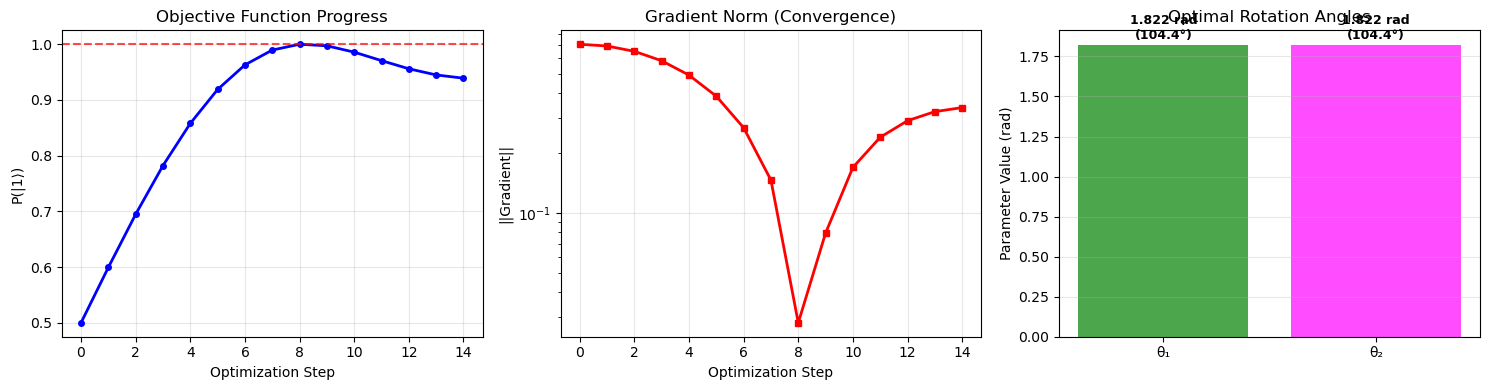


OPTIMIZATION SUMMARY
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Maximum probability: P(|1⟩) = 0.999610
Optimization steps: 15
Final gradient norm: 3.39e-01
JAX gradients enabled end-to-end quantum optimization!


In [56]:
import matplotlib.pyplot as plt
import numpy as np

# Check if we have optimization history
if len(objective_history) == 0:
    print("No optimization history available. Please run the optimization cell first.")
else:
    # Create simple visualization of optimization results
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    steps = np.arange(len(objective_history))

    # Plot 1: Optimization progress
    axes[0].plot(steps, objective_history, 'b-o', linewidth=2, markersize=4)
    axes[0].set_xlabel('Optimization Step')
    axes[0].set_ylabel('P(|1⟩)')
    axes[0].set_title('Objective Function Progress')
    axes[0].grid(True, alpha=0.3)
    if len(objective_history) > 0:
        axes[0].axhline(y=max(objective_history), color='r', linestyle='--', alpha=0.7)

    # Plot 2: Gradient norm (convergence indicator)
    if len(gradient_history) > 0 and max(gradient_history) > 0:
        axes[1].semilogy(steps, gradient_history, 'r-s', linewidth=2, markersize=4)
    else:
        axes[1].plot(steps, gradient_history, 'r-s', linewidth=2, markersize=4)
    axes[1].set_xlabel('Optimization Step')
    axes[1].set_ylabel('||Gradient||')
    axes[1].set_title('Gradient Norm (Convergence)')
    axes[1].grid(True, alpha=0.3)

    # Plot 3: Final optimized parameters
    try:
        theta1_final = float(params[0])
        theta2_final = float(params[1])
        param_names = ['θ₁', 'θ₂']
        param_values = [theta1_final, theta2_final]
        param_degrees = [theta1_final*180/np.pi, theta2_final*180/np.pi]

        bars = axes[2].bar(param_names, param_values, color=['green', 'magenta'], alpha=0.7)
        axes[2].set_ylabel('Parameter Value (rad)')
        axes[2].set_title('Optimal Rotation Angles')
        axes[2].grid(True, alpha=0.3, axis='y')

        # Add value labels on bars
        for i, (bar, rad_val, deg_val) in enumerate(zip(bars, param_values, param_degrees)):
            height = bar.get_height()
            axes[2].text(bar.get_x() + bar.get_width()/2., height + 0.02,
                        f'{rad_val:.3f} rad\n({deg_val:.1f}°)',
                        ha='center', va='bottom', fontweight='bold', fontsize=9)
    except:
        # Fallback if params not available
        axes[2].text(0.5, 0.5, 'Parameters not available', 
                    ha='center', va='center', transform=axes[2].transAxes)
        axes[2].set_title('Optimal Rotation Angles')

    plt.tight_layout()
    plt.show()


    max_prob = np.max(objective_history)
    print(f"\nOPTIMIZATION SUMMARY")
    print(f"━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
    print(f"Maximum probability: P(|1⟩) = {max_prob:.6f}")
    print(f"Optimization steps: {len(objective_history)}")
    if len(gradient_history) > 0:
        print(f"Final gradient norm: {gradient_history[-1]:.2e}")
    print(f"JAX gradients enabled end-to-end quantum optimization!")
